In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
    recall_score
)

from xgboost import XGBClassifier, plot_importance

In [24]:
df = pd.read_csv("/Users/ren/Downloads/auracheck/Dataset/students_mental_health_survey_with_burnout_final.csv")
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,...,Residence_Type,burnout_composite_score,burnout,burnout_raw_score,method1_tertiles,method2_wider,method3_very_wide,method4_manual,method5_manual2,method6_kmeans
0,29,Medical,Female,3.69,5,0,3,Good,Low,Average,...,On-Campus,0.199412,0,2.666667,1,1,1,1,1,1
1,24,Business,Female,3.75,1,3,0,Good,Low,Average,...,On-Campus,-0.610848,0,1.333333,0,0,1,0,0,0
2,25,Engineering,Male,3.15,3,2,4,Good,Moderate,Average,...,Off-Campus,0.408598,0,3.000000,2,2,2,1,1,2
3,18,Law,Male,3.97,1,1,5,Poor,Moderate,Average,...,With Family,0.001607,0,2.333333,1,1,1,1,1,1
4,25,Law,Female,3.13,4,3,5,Average,Moderate,Average,...,On-Campus,1.021761,1,4.000000,2,2,2,2,2,2


In [25]:
FEATURES_PRUNED = [
    "Course", "Gender", "Sleep_Quality", "Physical_Activity", "Diet_Quality",
    "Social_Support", "Relationship_Status", "Substance_Use", "Counseling_Service_Use",
    "Family_History", "Chronic_Illness", "Financial_Stress",
    "Extracurricular_Involvement", "Residence_Type"
]

ENCODING_MAP = {
    "Gender": {"Female": 0, "Male": 1},
    "Sleep_Quality": {"Poor": 0, "Average": 1, "Good": 2},
    "Physical_Activity": {"Low": 0, "Moderate": 1, "High": 2},
    "Diet_Quality": {"Good": 0, "Average": 1, "Poor": 2},
    "Social_Support": {"High": 0, "Moderate": 1, "Low": 2},
    "Substance_Use": {"Never": 0, "Unknown": 1, "Occasionally": 2, "Frequently": 3},
    "Counseling_Service_Use": {"Never": 0, "Occasionally": 1, "Frequently": 2},
    "Family_History": {"No": 0, "Yes": 1},
    "Chronic_Illness": {"No": 0, "Yes": 1},
    "Extracurricular_Involvement": {"High": 0, "Moderate": 1, "Low": 2},
    "Course": {"Business": 0, "Computer Science": 1, "Engineering": 2, "Law": 3, "Medical": 4, "Others": 5},
    "Relationship_Status": {"In a Relationship": 0, "Married": 1, "Single": 2},
    "Residence_Type": {"Off-Campus": 0, "On-Campus": 1, "With Family": 2},
}

In [26]:
def preprocess(df, features):
    X = df[features].copy()

    for c in X.columns:
        if X[c].isnull().any():
            if X[c].dtype == object:
                X[c] = X[c].fillna("Unknown")
            else:
                X[c] = X[c].fillna(X[c].median())

    for c, m in ENCODING_MAP.items():
        if c in X.columns:
            X[c] = X[c].astype(str).map(m).fillna(1)

    return X.astype(float)

In [27]:
X = preprocess(df, FEATURES_PRUNED)

y = pd.qcut(
    df["burnout_raw_score"].astype(float),
    q=4,
    labels=[0, 1, 2, 3],
    duplicates="drop"
).astype(int)

print(X.shape)
print(y.value_counts().sort_index())

(10000, 14)
burnout_raw_score
0    3028
1    2760
2    2330
3    1882
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 14)
Test shape: (2000, 14)


In [29]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [30]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
kappa = cohen_kappa_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(macro_f1, 4))
print("Macro Recall:", round(macro_recall, 4))
print("Cohen's Kappa:", round(kappa, 4))

Accuracy: 0.282
Macro F1: 0.2456
Macro Recall: 0.2574
Cohen's Kappa: 0.0118


In [32]:
class_names = ["Very Low (Q1)", "Low (Q2)", "Moderate (Q3)", "High (Q4)"]

print(classification_report(y_test, y_pred, target_names=class_names))

               precision    recall  f1-score   support

Very Low (Q1)       0.33      0.48      0.39       606
     Low (Q2)       0.26      0.27      0.26       552
Moderate (Q3)       0.25      0.21      0.23       466
    High (Q4)       0.19      0.07      0.10       376

     accuracy                           0.28      2000
    macro avg       0.26      0.26      0.25      2000
 weighted avg       0.26      0.28      0.26      2000



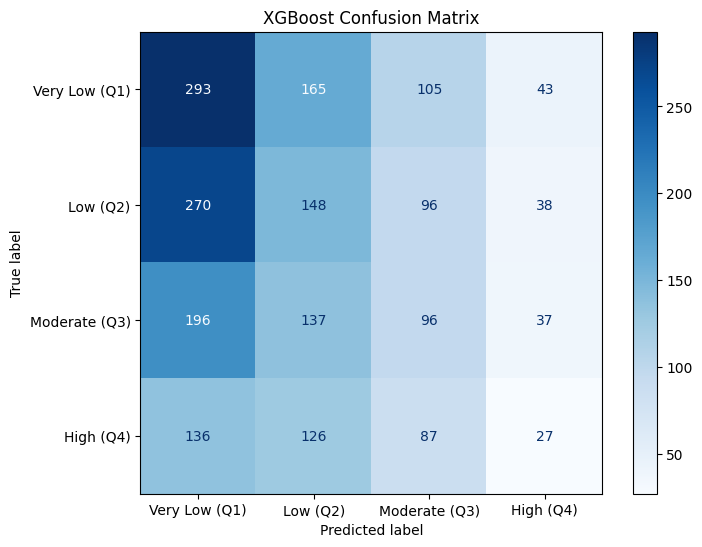

In [33]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.savefig("xgboost_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


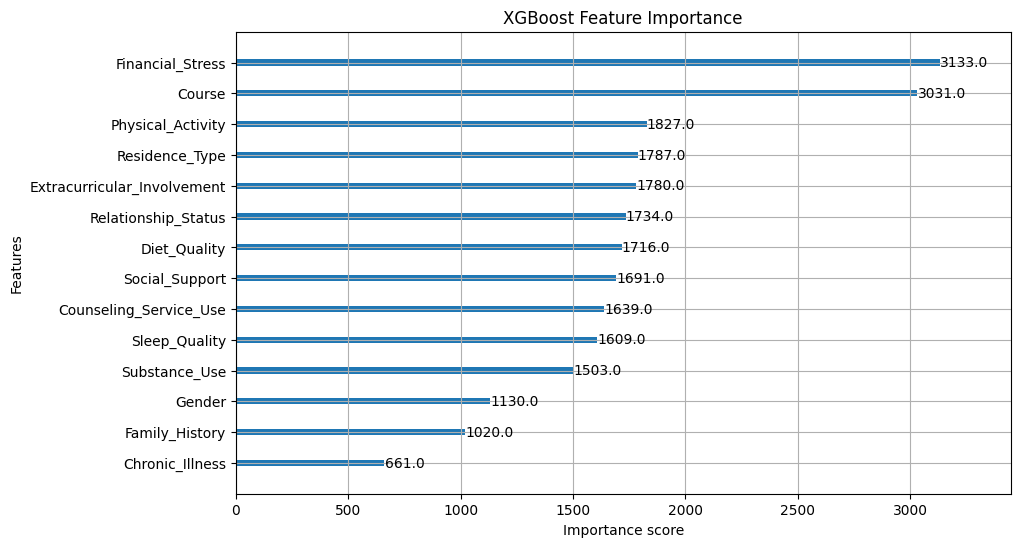

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb, ax=ax, max_num_features=14)
plt.title("XGBoost Feature Importance")
plt.savefig("xgboost_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [35]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_tune = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

grid = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV score: 0.26362764113465903


In [36]:
best_xgb = grid.best_estimator_

y_pred_best = best_xgb.predict(X_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
macro_f1_best = f1_score(y_test, y_pred_best, average="macro")
macro_recall_best = recall_score(y_test, y_pred_best, average="macro")
kappa_best = cohen_kappa_score(y_test, y_pred_best)

print("Tuned XGBoost Results")
print("Accuracy:", round(accuracy_best, 4))
print("Macro F1:", round(macro_f1_best, 4))
print("Macro Recall:", round(macro_recall_best, 4))
print("Cohen's Kappa:", round(kappa_best, 4))

Tuned XGBoost Results
Accuracy: 0.2885
Macro F1: 0.2583
Macro Recall: 0.2661
Cohen's Kappa: 0.023


In [37]:
results_df = X_test.copy()

results_df["true_label"] = y_test
results_df["predicted_label"] = y_pred_best

# optional: add probabilities
probs = best_xgb.predict_proba(X_test)

for i in range(probs.shape[1]):
    results_df[f"prob_class_{i}"] = probs[:, i]

results_df.to_csv("xgboost_predictions.csv", index=False)

In [17]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Macro Recall", "Kappa"],
    "Value": [accuracy_best, macro_f1_best, macro_recall_best, kappa_best]
})

metrics_df.to_csv("xgboost_metrics.csv", index=False)

In [38]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_best, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("xgboost_classification_report.csv")

report_df

,precision,recall,f1-score,support
0,0.337264,0.471947,0.393398,606.0000
1,0.261745,0.282609,0.271777,552.0000
2,0.247423,0.206009,0.224824,466.0000
3,0.232143,0.103723,0.143382,376.0000
accuracy,0.288500,0.288500,0.288500,0.2885
macro avg,0.269644,0.266072,0.258345,2000.0000
weighted avg,0.275725,0.288500,0.273550,2000.0000


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(cm)
cm_df.to_csv("xgboost_confusion_matrix.csv")

In [40]:
feat_imp_df = pd.DataFrame({
    "Feature": FEATURES_PRUNED,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_imp_df.to_csv("xgboost_feature_importance.csv", index=False)